paths

In [1]:
from pathlib import Path

# Base directory for all data
path_to_notebook = Path(r"C:\Users\Nima\Desktop\test\data")

# Specific data paths (all relative to path_to_notebook)
particle_data_path = path_to_notebook / "particleData"
sun_position_path   = path_to_notebook / "Sun_position"
v_circ_path         = path_to_notebook
dm_mass_path        = path_to_notebook / "dm_mass"


formulae

In [2]:
import numpy as np

# ─── 1. Cartesian → Spherical velocities ────────────────────────────────────────
def v_r(x, y, z, vx, vy, vz):
    """Radial velocity."""
    r = np.sqrt(x**2 + y**2 + z**2)
    return (x/r)*vx + (y/r)*vy + (z/r)*vz

def v_theta(x, y, z, vx, vy, vz):
    """Polar (θ) velocity."""
    r   = np.sqrt(x**2 + y**2 + z**2)
    rho = np.sqrt(x**2 + y**2)
    return (z*x/(r*rho))*vx + (z*y/(r*rho))*vy - (rho/r)*vz

def v_phi(x, y, z, vx, vy, vz):
    """Azimuthal (φ) velocity."""
    rho = np.sqrt(x**2 + y**2)
    return -(y/rho)*vx + (x/rho)*vy


# ─── 2. Detector frame ─────────────────────────────────────────────────────────
def lambda_sun(t):
    return 2*np.pi*(t - 0.218)

def v_ex(t):
    lam = lambda_sun(t)
    return 11.1 + 29.8*(-0.067*np.sin(lam) + 0.9931*np.cos(lam))

def v_ey(t, vc):
    lam = lambda_sun(t)
    return vc + 12.24 + 29.8*(0.4927*np.sin(lam) + 0.1170*np.cos(lam))

def v_ez(t):
    lam = lambda_sun(t)
    return 7.25 + 29.8*(-0.8676*np.sin(lam) - 0.01032*np.cos(lam))

def v_e(t, vc):
    return np.sqrt(v_ex(t)**2 + v_ey(t, vc)**2 + v_ez(t)**2)


# ─── 3. Lab frame w.r.t. galactic center ────────────────────────────────────────
def v_lab_x(t):
    return -v_ex(t)

def v_lab_y(t, vc):
    return v_ey(t, vc)

def v_lab_z(t):
    return -v_ez(t)

def v_lab_x_phi(t, vc, phi):
    return -np.cos(phi)*v_ex(t) - np.sin(phi)*v_ey(t, vc)

def v_lab_y_phi(t, vc, phi):
    return -np.sin(phi)*v_ex(t) + np.cos(phi)*v_ey(t, vc)

def v_lab_z_phi(t):
    return -v_ez(t)


# ─── 4. DM particles w.r.t. Lab frame ──────────────────────────────────────────
def v_lx(u_gx, t):
    return u_gx - v_lab_x(t)

def v_ly(u_gy, t, vc):
    return u_gy - v_lab_y(t, vc)

def v_lz(u_gz, t):
    return u_gz - v_lab_z(t)

def v_lx_phi(u_gx, t, vc, phi):
    return u_gx - v_lab_x_phi(t, vc, phi)

def v_ly_phi(u_gy, t, vc, phi):
    return u_gy - v_lab_y_phi(t, vc, phi)

def v_lz_phi(u_gz, t):
    return u_gz - v_lab_z_phi(t)


# ─── 5. Marius’s galactic‐sun frame ─────────────────────────────────────────────
def v_ex_g(t):
    lam = lambda_sun(t)
    return 11.1 + 29.8*(-0.067*np.sin(lam) + 0.9931*np.cos(lam))

def v_ey_g(t, vc):
    lam = lambda_sun(t)
    return vc + 12.24 + 29.8*(0.4927*np.sin(lam) + 0.1170*np.cos(lam))

def v_ez_g(t):
    lam = lambda_sun(t)
    return 7.25 + 29.8*(-0.8676*np.sin(lam) - 0.01032*np.cos(lam))

def v_e_g(t, vc):
    return np.sqrt(v_ex_g(t)**2 + v_ey_g(t, vc)**2 + v_ez_g(t)**2)

def v_ex_m(t, vc, x1, y1, z1):
    return v_ex_g(t)*x1 + v_ey_g(t, vc)*y1 + v_ez_g(t)*z1

def v_ey_m(t, vc, x2, y2, z2):
    return v_ex_g(t)*x2 + v_ey_g(t, vc)*y2 + v_ez_g(t)*z2

def v_ez_m(t, vc, x3, y3, z3):
    return v_ex_g(t)*x3 + v_ey_g(t, vc)*y3 + v_ez_g(t)*z3

def v_lx_m(u_gx, t, vc, x1, y1, z1):
    return u_gx - v_ex_m(t, vc, x1, y1, z1)

def v_ly_m(u_gy, t, vc, x2, y2, z2):
    return u_gy - v_ey_m(t, vc, x2, y2, z2)

def v_lz_m(u_gz, t, vc, x3, y3, z3):
    return u_gz - v_ez_m(t, vc, x3, y3, z3)


# ─── 6. Anisotropy parameter β ─────────────────────────────────────────────────
def anisotropy(dataset):
    """
    dataset: np.ndarray of shape (n, m)
      columns 11→vr, 12→vth, 13→vphi (0-based indexing).
    """
    vr   = dataset[:, 11]
    vth  = dataset[:, 12]
    vphi = dataset[:, 13]
    σ_vr   = np.std(vr,   ddof=1)
    σ_vth  = np.std(vth,  ddof=1)
    σ_vphi = np.std(vphi, ddof=1)
    return 1 - (σ_vth**2 + σ_vphi**2) / (2 * σ_vr**2)


# ─── 7. Escape velocity v_esc ──────────────────────────────────────────────────
def v_escape(dataset, factor):
    """
    dataset: np.ndarray of shape (n, m)
      columns 3–5 are the velocity components (0-based).
    """
    vels  = dataset[:, 3:6] * factor
    norms = np.linalg.norm(vels, axis=1)
    return np.max(norms)


Load data

In [3]:
!pip install h5py
import h5py
import numpy as np

def get_lmc_data_hdf5(hdf5_filename):
    """
    Load LMC dark matter data from an HDF5 file.

    Parameters
    ----------
    hdf5_filename : str or Path
        Path to the HDF5 file.

    Returns
    -------
    dm_pos : np.ndarray
        Array of particle coordinates.
    dm_vel : np.ndarray
        Array of particle velocities.
    dm_tag : np.ndarray
        Array of original particle tags.
    """
    with h5py.File(hdf5_filename, "r") as f:
        dm_pos = f["Coordinates"][()]
        dm_vel = f["Velocities"][()]
        dm_tag = f["LMC_tag"][()]
    return dm_pos, dm_vel, dm_tag



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Data construction

In [4]:
import numpy as np
import pandas as pd

# ─── Data construction ──────────────────────────────────────────────────────────
def build_dataset(coordinates, velocities, lmc_tag):
    """
    Construct a DataFrame combining positions, velocities, tags, radial filters, and spherical velocities.

    Parameters
    ----------
    coordinates : array-like, shape (N, 3)
        x, y, z positions.
    velocities : array-like, shape (N, 3)
        vx, vy, vz velocities.
    lmc_tag : array-like, shape (N,)
        Original LMC tags (-1 indicates MW).

    Returns
    -------
    df : pandas.DataFrame
        Columns:
        - x, y, z
        - vx, vy, vz
        - lmc_tag
        - mw_lmc
        - r_pos
        - r_6_10
        - r_7_9
        - v_r, v_theta, v_phi
    """
    coords     = np.asarray(coordinates)
    velos      = np.asarray(velocities)
    tags       = np.asarray(lmc_tag)

    x, y, z    = coords.T
    vx, vy, vz = velos.T

    # Tag classification
    mw_lmc     = np.where(tags == -1, 'mw', 'lmc')

    # Radial distances and filters
    r_pos      = np.linalg.norm(coords, axis=1)
    r_6_10     = ((r_pos >= 6.0) & (r_pos <= 10.0)).astype(int)
    r_7_9      = ((r_pos >= 7.0) & (r_pos <= 9.0)).astype(int)

    # Spherical velocities (using previously defined v_r, v_theta, v_phi)
    vr         = v_r(x, y, z, vx, vy, vz)
    v_theta_s  = v_theta(x, y, z, vx, vy, vz)
    v_phi_s    = v_phi(x, y, z, vx, vy, vz)

    # Assemble DataFrame
    df = pd.DataFrame({
        'x'      : x,
        'y'      : y,
        'z'      : z,
        'vx'     : vx,
        'vy'     : vy,
        'vz'     : vz,
        'lmc_tag': tags,
        'mw_lmc' : mw_lmc,
        'r_pos'  : r_pos,
        'r_6_10' : r_6_10,
        'r_7_9'  : r_7_9,
        'v_r'    : vr,
        'v_theta': v_theta_s,
        'v_phi'  : v_phi_s,
    })

    return df


Build a DataSet

In [5]:
def load_dataset(hdf5_filename):
    """
    Load raw LMC data from an HDF5 file and build the full dataset.

    Parameters
    ----------
    hdf5_filename : str or Path
        Path to the HDF5 file containing LMC data.

    Returns
    -------
    df : pandas.DataFrame
        Combined dataset with positions, velocities, tags, radial filters, and spherical velocities.
    """
    # Import raw data
    dm_pos, dm_vel, dm_tag = get_lmc_data_hdf5(hdf5_filename)

    # Build and return the dataset
    return build_dataset(dm_pos, dm_vel, dm_tag)


In [6]:
filename = r"C:\Users\Nima\Desktop\test\data\particleData\particleData_pair_49_snap_139.hdf5"
data = load_dataset(filename)
data

,x,y,z,vx,vy,vz,lmc_tag,mw_lmc,r_pos,r_6_10,r_7_9,v_r,v_theta,v_phi
0,-0.178008,-0.073146,0.021227,113.744072,52.729206,-26.897217,-1.000000,mw,0.193618,0,0,-127.443137,13.003402,-5.540920
1,-0.060236,-0.152928,-0.014963,68.800728,2.488624,-16.545507,-1.000000,mw,0.165043,0,0,-25.916051,18.973246,63.101992
2,0.009542,0.174691,-0.107407,81.813087,56.085884,-53.925041,-1.000000,mw,0.205291,0,0,79.742026,14.320790,-78.632321
3,0.202560,-0.317608,-0.108207,96.663422,38.817028,-44.006439,-1.000000,mw,0.391936,0,0,30.651250,36.981491,102.371947
4,0.056549,-0.057645,-0.095360,88.158340,-6.832232,-67.660805,-1.000000,mw,0.124957,0,0,94.682605,-7.111097,58.148031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238011,-7.116204,-8.110347,-9.848745,539.259888,129.924973,-173.465683,0.315702,lmc,14.608760,0,0,-217.869328,433.732986,319.657193
238012,-4.009159,-11.191335,-9.138623,513.461792,210.117920,-316.606323,-1.000000,mw,14.994458,0,0,-101.150979,477.105104,412.518261
238013,-1.315522,3.236037,-6.253296,388.444885,-17.337557,-487.723816,-1.000000,mw,7.162838,1,1,346.618040,379.587946,-353.317797
238014,-3.983718,-2.837483,-9.484252,585.623779,143.604233,-78.629196,0.713585,lmc,10.671099,0,0,-186.925007,534.028769,222.782972


The data cuts

In [7]:
def cut_dataset(data_matrix, particle_type, shell):
    """
    Filter the dataset by particle type and radial shell.

    Parameters
    ----------
    data_matrix : pandas.DataFrame
        The full dataset produced by `build_dataset`, with columns:
        - 'r_pos', 'r_6_10', 'r_7_9', 'mw_lmc', etc.
    particle_type : str
        One of 'dm', 'mw', or 'lmc'.
    shell : str or sequence of two floats
        If str, must be '6to10' or '7to9', selecting the precomputed shell flags.
        If sequence (Rmin, Rmax), selects rows with Rmin <= r_pos <= Rmax.

    Returns
    -------
    pandas.DataFrame
        The filtered subset of `data_matrix`.
    """
    import numpy as np

    # Validate particle_type
    if particle_type not in ('dm', 'mw', 'lmc'):
        raise ValueError('particle_type must be "dm", "mw", or "lmc"')

    df = data_matrix.copy()

    # Build the shell mask
    if isinstance(shell, str):
        if shell not in ('6to10', '7to9'):
            raise ValueError('If shell is a string, it must be "6to10" or "7to9"')
        col = 'r_6_10' if shell == '6to10' else 'r_7_9'
        mask = df[col] == 1

    elif (isinstance(shell, (list, tuple, np.ndarray))
          and len(shell) == 2):
        Rmin, Rmax = shell
        if not (0 <= Rmin < Rmax <= 15):
            raise ValueError(
                'For a numeric shell, provide [Rmin, Rmax] with '
                '0 ≤ Rmin < Rmax ≤ 15'
            )
        mask = df['r_pos'].between(Rmin, Rmax)

    else:
        raise ValueError(
            'shell must be either a string ("6to10"/"7to9") '
            'or a two‐element sequence [Rmin, Rmax]'
        )

    # Apply particle_type filter
    if particle_type != 'dm':
        mask &= (df['mw_lmc'] == particle_type)

    return df.loc[mask]


In [8]:
dmcutMatrix = cut_dataset(data, 'dm', '6to10')
mwcutMatrix = cut_dataset(data, 'mw', '6to10')
lmccutMatrix = cut_dataset(data, 'lmc', '6to10')

Loading Circular Velocities File based on sequence filenames

In [9]:
import numpy as np
import re
from pathlib import Path

# def name_num(filename):
#     """
#     Extract the 1- or 2-digit system number (and optional snapshot) from a filename.
    
#     Returns
#     -------
#     str or tuple(str, str) or None
#         - If only a system number is found, returns it as a string.
#         - If a snapshot is embedded, returns (system_number, snapshot).
#         - Returns None if no match.
#     """
#     # Work with the base name only
#     name = Path(filename).name
#     n = len(name)

#     if n == 23:
#         # 1-digit system, e.g. "..._N_xxx"
#         return name[17]
#     elif n == 24:
#         # 2-digit system
#         return name[17:19]
#     elif n == 33:
#         # 1-digit system + 3-char snapshot
#         system = name[18]
#         snap   = name[25:28]
#         return system, snap
#     elif n == 34:
#         # 2-digit system + 3-char snapshot
#         system = name[18:20]
#         snap   = name[27:30]
#         return system, snap
#     else:
#         # Could not match known patterns
#         return None

def name_num(filename):
    """
    Extract system and snapshot IDs from filenames like:
      '..._pair_{system}_snap_{snap}.hdf5'
    Returns
    -------
    tuple(str, str)
        (system_id, snapshot_id)
    or
    str
        If only a single ID is found.
    """
    name = Path(filename).stem  # e.g., 'particleData_pair_49_snap_139'
    # Match patterns 'pair_{system}_snap_{snap}'
    m = re.search(r'pair_(\d+)_snap_(\d+)', name)
    if m:
        return m.group(1), m.group(2)
    # Fallback: first sequence of digits
    m2 = re.search(r'(\d+)', name)
    if m2:
        return m2.group(1)
    return None


# ─── Load circular‐velocity data once ───────────────────────────────────────────
# Assumes v_circ_path is already defined as a Path to the directory containing "data_Vcirc_Sun.txt"
vc_data = np.loadtxt(v_circ_path / "data_Vcirc_Sun.txt")
# Rows 10..74 in Mathematica (1-based) → Python indices 9:74
vc_list = vc_data[9:74, [0, 2]]  # columns: [system_id, vc_value]
vc_map  = {int(row[0]): row[1] for row in vc_list}


def vc_system(filename):
    """
    Given a filename, return the local circular speed for that system.

    Parameters
    ----------
    filename : str or Path
        Path or name of the file whose system ID we extract.

    Returns
    -------
    float
        Circular speed v_c for that system.

    Raises
    ------
    ValueError
        If the system ID cannot be parsed.
    KeyError
        If the parsed system ID is not found in the circular‐velocity table.
    """
    parsed = name_num(filename)
    if isinstance(parsed, tuple):
        system_id = int(parsed[0])
    elif isinstance(parsed, str):
        system_id = int(parsed)
    else:
        raise ValueError(f"Cannot parse system ID from filename: {filename!s}")

    try:
        return vc_map[system_id]
    except KeyError:
        raise KeyError(f"System ID {system_id} not found in v_circ data")


In [10]:
vc = vc_system(filename)

In [11]:
import numpy as np
import pandas as pd
from pathlib import Path

# ─── Configure this to point at your Sun position directory ───────────────────
sun_position_path = path_to_notebook / "Sun_position"

# ─── 1. Locate the Sun‐position files ──────────────────────────────────────────
# ─── Corrected: Sun position file locator ─────────────────────────────────────
def get_sun_position_location():
    """
    Return the directory containing Sun_LMC_*.txt.
    Checks for a non-None global `snapshot_path`, else uses `sun_position_path`.
    """
    if 'snapshot_path' in globals() and snapshot_path:
        return Path(snapshot_path)
    return Path(sun_position_path)

# ─── 2. Extract Sun position closest to fixed cosines ─────────────────────────
def sun_position(filename):
    """
    Return the 9‐element Sun position and its index in the file
    that best matches cos_sv_lr = -0.835 and cos_sv_lv = -0.709.
    """
    sun_dir = get_sun_position_location()
    parsed = name_num(filename)
    system_id = parsed[1] if isinstance(parsed, tuple) else str(parsed)
    file_path = sun_dir / f"Sun_LMC_{system_id}.txt"

    df = pd.read_csv(
        file_path,
        delim_whitespace=True,
        header=None,
        comment='#',
        on_bad_lines='skip'
    )
    data = df.to_numpy(dtype=float)

    cos_lr = data[:, 9]
    cos_lv = data[:, 10]
    target_lr, target_lv = -0.835, -0.709

    idx = int(np.argmin((cos_lr - target_lr)**2 + (cos_lv - target_lv)**2))
    sun_pos = data[idx, :9]
    return sun_pos, idx

# ─── 3. Best‐fit Sun position for arbitrary cosines ────────────────────────────
def best_fit_sun_position(filename, cos_sv_lr, cos_sv_lv):
    """
    Given desired cos_sv_lr and cos_sv_lv, return the best‐matching
    (cos_lr, cos_lv) pair and its row index.
    """
    sun_dir = get_sun_position_location()
    parsed = name_num(filename)
    system_id = parsed[1] if isinstance(parsed, tuple) else str(parsed)
    file_path = sun_dir / f"Sun_LMC_{system_id}.txt"

    df = pd.read_csv(
        file_path,
        delim_whitespace=True,
        header=None,
        comment='#',
        on_bad_lines='skip'
    )
    data = df.to_numpy(dtype=float)

    cos_lr = data[:, 9]
    cos_lv = data[:, 10]
    diffs = (cos_lr - cos_sv_lr)**2 + (cos_lv - cos_sv_lv)**2

    idx = int(np.argmin(diffs))
    best_cosines = data[idx, 9:11]
    return best_cosines, idx

# ─── 4. Retrieve all Sun positions and cosines ────────────────────────────────
def all_sun_positions(filename):
    """
    Return list of all 9‐element positions and array of all (cos_lr, cos_lv).
    """
    sun_dir = get_sun_position_location()
    parsed = name_num(filename)
    system_id = parsed[1] if isinstance(parsed, tuple) else str(parsed)
    file_path = sun_dir / f"Sun_LMC_{system_id}.txt"

    df = pd.read_csv(
        file_path,
        delim_whitespace=True,
        header=None,
        comment='#',
        on_bad_lines='skip'
    )
    data = df.to_numpy(dtype=float)

    positions = [row[:9] for row in data]
    cos_table = data[:, 9:11]
    return positions, cos_table

# ─── 5. Minimize |sv_lr - const| ───────────────────────────────────────────────
def sun_sv_lr_min_position(filename):
    """
    Return the position minimizing |cos_sv_lr + 0.835| and its index.
    """
    sun_dir = get_sun_position_location()
    parsed = name_num(filename)
    system_id = parsed[1] if isinstance(parsed, tuple) else str(parsed)
    file_path = sun_dir / f"Sun_LMC_{system_id}.txt"

    df = pd.read_csv(
        file_path,
        delim_whitespace=True,
        header=None,
        comment='#',
        on_bad_lines='skip'
    )
    data = df.to_numpy(dtype=float)

    cos_lr = data[:, 9]
    diffs = np.abs(cos_lr + 0.835)
    idx = int(np.argmin(diffs))
    sun_pos = data[idx, :9]
    return sun_pos, idx

# ─── 6. Minimize |sv_lv - const| ───────────────────────────────────────────────
def sun_sv_lv_min_position(filename):
    """
    Return the position minimizing |cos_sv_lv + 0.709| and its index.
    """
    sun_dir = get_sun_position_location()
    parsed = name_num(filename)
    system_id = parsed[1] if isinstance(parsed, tuple) else str(parsed)
    file_path = sun_dir / f"Sun_LMC_{system_id}.txt"

    df = pd.read_csv(
        file_path,
        delim_whitespace=True,
        header=None,
        comment='#',
        on_bad_lines='skip'
    )
    data = df.to_numpy(dtype=float)

    cos_lv = data[:, 10]
    diffs = np.abs(cos_lv + 0.709)
    idx = int(np.argmin(diffs))
    sun_pos = data[idx, :9]
    return sun_pos, idx

# ─── 7. Random Sun position selection ───────────────────────────────────────────
def random_sun_position(filename):
    """
    Pick a random Sun position and return it with its index.
    """
    sun_dir = get_sun_position_location()
    parsed = name_num(filename)
    system_id = parsed[1] if isinstance(parsed, tuple) else str(parsed)
    file_path = sun_dir / f"Sun_LMC_{system_id}.txt"

    df = pd.read_csv(
        file_path,
        delim_whitespace=True,
        header=None,
        comment='#',
        on_bad_lines='skip'
    )
    data = df.to_numpy(dtype=float)

    idx = int(np.random.randint(0, len(data)))
    sun_pos = data[idx, :9]
    return sun_pos, idx

# ─── 8. Interactive choice of Sun position ─────────────────────────────────────
def choose_sun_position(filename):
    """
    Prompt user to choose a row index to select Sun position.
    """
    sun_dir = get_sun_position_location()
    parsed = name_num(filename)
    system_id = parsed[1] if isinstance(parsed, tuple) else str(parsed)
    file_path = sun_dir / f"Sun_LMC_{system_id}.txt"

    df = pd.read_csv(
        file_path,
        delim_whitespace=True,
        header=None,
        comment='#',
        on_bad_lines='skip'
    )
    data = df.to_numpy(dtype=float)

    max_idx = len(data) - 1
    idx = int(input(f"Enter an index between 0 and {max_idx}: "))
    sun_pos = data[idx, :9]
    return sun_pos, idx

# ─── 9. Direct index selection ─────────────────────────────────────────────────
def choose_sun_position_num(filename, idx):
    """
    Return the Sun position at the specified index without prompting.
    """
    sun_dir = get_sun_position_location()
    parsed = name_num(filename)
    system_id = parsed[1] if isinstance(parsed, tuple) else str(parsed)
    file_path = sun_dir / f"Sun_LMC_{system_id}.txt"

    df = pd.read_csv(
        file_path,
        delim_whitespace=True,
        header=None,
        comment='#',
        on_bad_lines='skip'
    )
    data = df.to_numpy(dtype=float)

    sun_pos = data[idx, :9]
    return sun_pos, idx


In [12]:
sunPos, row = sun_position(filename)

C:\Users\Nima\AppData\Local\Temp\ipykernel_13500\3493127806.py:30: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


Dot‐product cuts for the cone

In [13]:
import numpy as np
import pandas as pd

# ─── 1. Dot‐product cut for a fixed φ ───────────────────────────────────────────
def dot_product_cut(df: pd.DataFrame, phi: float) -> pd.DataFrame:
    """
    Select rows where the dot product of (x, y) with the direction φ
    exceeds the cone cosine threshold (π/4).

    Parameters
    ----------
    df  : DataFrame
        Must contain columns 'x', 'y', and 'r_pos'.
    phi : float
        Azimuthal angle in radians.

    Returns
    -------
    DataFrame
        Subset of df passing the dot‐product cut.
    """
    cos_alpha_cone = np.cos(np.pi / 4)
    cos_alpha = (df['x'] * np.cos(phi) +
                 df['y'] * np.sin(phi)) / df['r_pos']
    mask = cos_alpha >= cos_alpha_cone
    return df.loc[mask]


# ─── 2. Dot‐product cut using a given Sun‐position vector ───────────────────────
def dot_product_sun_position(df: pd.DataFrame, sun_pos: np.ndarray) -> pd.DataFrame:
    """
    Select rows where the dot product of (x, y, z) with the Sun‐position vector
    (negated) exceeds the cone cosine threshold (π/4).

    Parameters
    ----------
    df      : DataFrame
        Must contain columns 'x', 'y', 'z', and 'r_pos'.
    sun_pos : array‐like of length 3
        Sun position [x1, x2, x3].

    Returns
    -------
    DataFrame
        Subset of df passing the dot‐product cut with the Sun‐position vector.
    """
    x1, x2, x3 = sun_pos[:3]
    cos_alpha_cone = np.cos(np.pi / 4)
    cos_alpha = -(x1 * df['x'] +
                  x2 * df['y'] +
                  x3 * df['z']) / df['r_pos']
    mask = cos_alpha >= cos_alpha_cone
    return df.loc[mask]

# Example usage:
# df_cut = dot_product_cut(data_frame, phi_s)
# df_sun = dot_product_sun_position(data_frame, sun_position_array)


In [14]:
dmsun = dot_product_sun_position(dmcutMatrix, sunPos)
mwsun = dot_product_sun_position(mwcutMatrix, sunPos)
lmcsun = dot_product_sun_position(lmccutMatrix, sunPos)

3D transformation to detector reference frame

In [15]:
import numpy as np
from pathlib import Path

def lab_frame_marius(data_matrix, vc, sun_pos):
    """
    Compute lab-frame (Marius) velocities for 12 detector rotations.

    Parameters
    ----------
    data_matrix : pandas.DataFrame
        Must contain columns 'vx', 'vy', 'vz' for particle velocities.
    vc : float
        Local circular speed parameter.
    sun_pos : array-like of length 9
        Sun-position matrix entries [x1, x2, x3, y1, y2, y3, z1, z2, z3].

    Returns
    -------
    vx_lab_list, vy_lab_list, vz_lab_list : list of np.ndarray
        Each list has 12 arrays (one per rotation) of shape (N,),
        giving the transformed lab-frame velocities.
    """
    # Extract velocities as an (N,3) array
    vel = data_matrix[['vx', 'vy', 'vz']].to_numpy()

    # Unpack the Sun-position basis matrix
    x1, x2, x3 = sun_pos[0:3]
    y1, y2, y3 = sun_pos[3:6]
    z1, z2, z3 = sun_pos[6:9]

    # 12 evenly spaced rotation times (fractions of a full rotation)
    times = np.arange(12) / 12.0

    vx_lab_list = []
    vy_lab_list = []
    vz_lab_list = []

    for t in times:
        # Marius‐frame velocity components
        v_exm = v_ex_g(t) * x1 + v_ey_g(t, vc) * y1 + v_ez_g(t) * z1
        v_eym = v_ex_g(t) * x2 + v_ey_g(t, vc) * y2 + v_ez_g(t) * z2
        v_ezm = v_ex_g(t) * x3 + v_ey_g(t, vc) * y3 + v_ez_g(t) * z3

        # Lab‐frame velocities = Galactic velocities minus Sun motion
        vx_lab_list.append(vel[:, 0] - v_exm)
        vy_lab_list.append(vel[:, 1] - v_eym)
        vz_lab_list.append(vel[:, 2] - v_ezm)

    return vx_lab_list, vy_lab_list, vz_lab_list


In [18]:
# Create shell subsets
dmsun  = cut_dataset(data, 'dm',  [6,10])
mwsun  = cut_dataset(data, 'mw',  [6,10])
lmcsun = cut_dataset(data, 'lmc', [6,10])

# Compute lab‐frame velocities
dmvDet  = lab_frame_marius(dmsun,  vc, sunPos)
mwvDet  = lab_frame_marius(mwsun,  vc, sunPos)
lmcvDet = lab_frame_marius(lmcsun, vc, sunPos)

dm_vx, dm_vy, dm_vz   = dmvDet
mw_vx, mw_vy, mw_vz   = mwvDet
lmc_vx, lmc_vy, lmc_vz = lmcvDet

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from IPython.display import HTML

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, rc
from IPython.display import HTML

# ─── Precomputed dm_vx, dm_vy, dm_vz, mw_vx, mw_vy, mw_vz, lmc_vx, lmc_vy, lmc_vz ───
# (Ensure these are defined in prior cells)

# Determine common bin range
all_speeds = []
for idx in range(12):
    all_speeds.extend(np.sqrt(dm_vx[idx]**2 + dm_vy[idx]**2 + dm_vz[idx]**2))
    all_speeds.extend(np.sqrt(mw_vx[idx]**2 + mw_vy[idx]**2 + mw_vz[idx]**2))
    all_speeds.extend(np.sqrt(lmc_vx[idx]**2 + lmc_vy[idx]**2 + lmc_vz[idx]**2))
max_speed = np.max(all_speeds)
bins = np.linspace(0, max_speed, 50)

# Setup figure and axes
fig, ax = plt.subplots(figsize=(8, 5))

def animate(frame_idx):
    ax.clear()
    speeds_dm  = np.sqrt(dm_vx[frame_idx]**2  + dm_vy[frame_idx]**2  + dm_vz[frame_idx]**2)
    speeds_mw  = np.sqrt(mw_vx[frame_idx]**2  + mw_vy[frame_idx]**2  + mw_vz[frame_idx]**2)
    speeds_lmc = np.sqrt(lmc_vx[frame_idx]**2 + lmc_vy[frame_idx]**2 + lmc_vz[frame_idx]**2)
    ax.hist(speeds_dm,  bins=bins, density=True, histtype='step', label='DM')
    ax.hist(speeds_mw,  bins=bins, density=True, histtype='step', label='MW')
    ax.hist(speeds_lmc, bins=bins, density=True, histtype='step', label='LMC')
    ax.set_xlabel('Speed (km/s)')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'Speed Distributions at rotation index {frame_idx}')
    ax.legend(loc='upper right')

# Configure animation to render as JS HTML in Jupyter
rc('animation', html='jshtml')
anim = animation.FuncAnimation(fig, animate, frames=12, interval=500)

# This suppresses the static figure so only the animation shows
plt.close(fig)

# Display animation
HTML(anim.to_jshtml())



In [19]:
# ─── Cell 1: Imports, constants, and function definitions ──────────────────────
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import re

# ─── Paths ─────────────────────────────────────────────────────────────────────
BASE_PATH           = Path(r"C:\Users\Nima\Desktop\test\data")
PARTICLE_PATH       = BASE_PATH / "particleData"
SUN_POSITION_PATH   = BASE_PATH / "Sun_position"
VC_CIRC_FILE        = BASE_PATH / "data_Vcirc_Sun.txt"

# ─── Load circular‐velocity table once ─────────────────────────────────────────
_vc_data = np.loadtxt(VC_CIRC_FILE)
_vc_list = _vc_data[9:74, [0,2]]                      # rows 10–74, cols system_id & vc
_VC_MAP  = {int(row[0]): row[1] for row in _vc_list}

def name_num(filename):
    """Extract (system_id, snapshot) from '…_pair_{sys}_snap_{snap}.hdf5'."""
    stem = Path(filename).stem
    m = re.search(r'pair_(\d+)_snap_(\d+)', stem)
    if m:
        return m.group(1), m.group(2)
    m2 = re.search(r'(\d+)', stem)
    return (m2.group(1),) if m2 else None

def vc_system(filename):
    """Return the local circular speed v_c for this file's system."""
    parsed = name_num(filename)
    sys_id = int(parsed[0])
    return _VC_MAP[sys_id]

# ─── Spherical Velocities ─────────────────────────────────────────────────────
def v_r(x, y, z, vx, vy, vz):
    r = np.sqrt(x*x + y*y + z*z)
    return (x*vx + y*vy + z*vz)/r

def v_theta(x, y, z, vx, vy, vz):
    r   = np.sqrt(x*x + y*y + z*z)
    rho = np.sqrt(x*x + y*y)
    return (z*x*vx + z*y*vy - rho*r*vz)/(r*rho)

def v_phi(x, y, z, vx, vy, vz):
    rho = np.sqrt(x*x + y*y)
    return (-y*vx + x*vy)/rho

# ─── HDF5 loader & DataFrame builder ──────────────────────────────────────────
def get_lmc_data_hdf5(fn):
    with h5py.File(fn, "r") as f:
        return f["Coordinates"][()], f["Velocities"][()], f["LMC_tag"][()]

def build_dataset(coords, velos, tags):
    coords = np.asarray(coords)
    velos  = np.asarray(velos)
    x, y, z    = coords.T
    vx, vy, vz = velos.T
    mw_lmc = np.where(np.asarray(tags)==-1, "mw", "lmc")
    r_pos  = np.linalg.norm(coords, axis=1)
    r_6_10 = ((r_pos>=6)&(r_pos<=10)).astype(int)
    vr    = v_r(x,y,z, vx,vy,vz)
    vth   = v_theta(x,y,z, vx,vy,vz)
    vph   = v_phi(x,y,z, vx,vy,vz)
    return pd.DataFrame({
        "x":x, "y":y, "z":z,
        "vx":vx, "vy":vy, "vz":vz,
        "lmc_tag": tags,
        "mw_lmc":  mw_lmc,
        "r_pos":   r_pos, "r_6_10": r_6_10,
        "v_r": vr, "v_theta": vth, "v_phi": vph,
    })

def load_dataset(fn):
    coords, velos, tags = get_lmc_data_hdf5(fn)
    return build_dataset(coords, velos, tags)

# ─── Shell‐cut utility ─────────────────────────────────────────────────────────
def cut_dataset(df, particle_type, shell):
    """
    df            : DataFrame from build_dataset
    particle_type: "dm", "mw" or "lmc"
    shell         : [Rmin, Rmax] in kpc
    """
    if particle_type not in ("dm","mw","lmc"):
        raise ValueError('particle_type must be "dm","mw" or "lmc"')
    Rmin, Rmax = shell
    mask = df["r_pos"].between(Rmin, Rmax)
    if particle_type!="dm":
        mask &= (df["mw_lmc"]==particle_type)
    return df.loc[mask]

# ─── Sun‐motion vectors in galactic‐sun frame ─────────────────────────────────
def lambda_sun(t):
    return 2*np.pi*(t - 0.218)

def v_ex_g(t):
    lam = lambda_sun(t)
    return 11.1 + 29.8*(-0.067*np.sin(lam) + 0.9931*np.cos(lam))

def v_ey_g(t, vc):
    lam = lambda_sun(t)
    return vc + 12.24 + 29.8*(0.4927*np.sin(lam) + 0.1170*np.cos(lam))

def v_ez_g(t):
    lam = lambda_sun(t)
    return 7.25 + 29.8*(-0.8676*np.sin(lam) - 0.01032*np.cos(lam))

# ─── Sun‐position lookup ───────────────────────────────────────────────────────
def sun_position(filename):
    """
    Return best‐match Sun position (first 9 columns) and its row index,
    minimizing (cos_sv_lr+0.835)^2+(cos_sv_lv+0.709)^2.
    """
    parsed = name_num(filename)
    sys_id = parsed[1] if len(parsed)>1 else parsed[0]
    fn     = SUN_POSITION_PATH / f"Sun_LMC_{sys_id}.txt"
    data   = pd.read_csv(fn, delim_whitespace=True, header=None,
                         comment="#", on_bad_lines="skip").to_numpy(float)
    cos_lr, cos_lv = data[:,9], data[:,10]
    idx = int(np.argmin((cos_lr+0.835)**2 + (cos_lv+0.709)**2))
    return data[idx,:9], idx

# ─── Cone cut along Sun direction ──────────────────────────────────────────────
def dot_product_sun_position(df, sun_pos):
    x1, x2, x3 = sun_pos[:3]
    cos_a = -(x1*df["x"] + x2*df["y"] + x3*df["z"]) / df["r_pos"]
    return df.loc[cos_a >= np.cos(np.pi/4)]

# ─── Lab‐frame velocities (Marius’ method) ────────────────────────────────────
def lab_frame_marius(df, vc, sun_pos):
    vel = df[["vx","vy","vz"]].to_numpy()
    x1,x2,x3 = sun_pos[0:3]
    y1,y2,y3 = sun_pos[3:6]
    z1,z2,z3 = sun_pos[6:9]
    times = np.arange(12)/12.0
    vx_list, vy_list, vz_list = [], [], []
    for t in times:
        v_exm = v_ex_g(t)*x1 + v_ey_g(t,vc)*y1 + v_ez_g(t)*z1
        v_eym = v_ex_g(t)*x2 + v_ey_g(t,vc)*y2 + v_ez_g(t)*z2
        v_ezm = v_ex_g(t)*x3 + v_ey_g(t,vc)*y3 + v_ez_g(t)*z3
        vx_list.append( vel[:,0] - v_exm )
        vy_list.append( vel[:,1] - v_eym )
        vz_list.append( vel[:,2] - v_ezm )
    return vx_list, vy_list, vz_list


C:\Users\Nima\AppData\Local\Temp\ipykernel_13500\1329616840.py:117: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data   = pd.read_csv(fn, delim_whitespace=True, header=None,


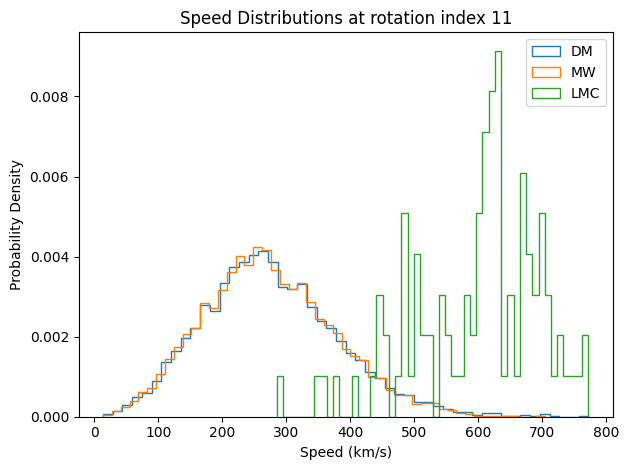

In [23]:
# ─── Cell 2: Main pipeline + final plot ────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

# 1. File, vc, and Sun position
filename      = PARTICLE_PATH / "particleData_pair_49_snap_139.hdf5"
vc            = vc_system(filename)
sun_pos, idx  = sun_position(filename)

# 2. Load & slice the dataset
df_all    = load_dataset(filename)
df_dm     = cut_dataset(df_all, "dm",  [6,10])
df_mw     = cut_dataset(df_all, "mw",  [6,10])
df_lmc    = cut_dataset(df_all, "lmc", [6,10])

# 3. Cone‐cut along Sun direction
df_dm_sun  = dot_product_sun_position(df_dm,  sun_pos)
df_mw_sun  = dot_product_sun_position(df_mw,  sun_pos)
df_lmc_sun = dot_product_sun_position(df_lmc, sun_pos)

# 4. Compute lab‐frame velocities
dm_vx, dm_vy, dm_vz   = lab_frame_marius(df_dm_sun,  vc, sun_pos)
mw_vx, mw_vy, mw_vz   = lab_frame_marius(df_mw_sun,  vc, sun_pos)
lmc_vx, lmc_vy, lmc_vz = lab_frame_marius(df_lmc_sun, vc, sun_pos)

# 5. Choose rotation index & compute speeds
time_idx   = 11
speeds_dm  = np.sqrt(dm_vx[time_idx]**2  + dm_vy[time_idx]**2  + dm_vz[time_idx]**2)
speeds_mw  = np.sqrt(mw_vx[time_idx]**2  + mw_vy[time_idx]**2  + mw_vz[time_idx]**2)
speeds_lmc = np.sqrt(lmc_vx[time_idx]**2 + lmc_vy[time_idx]**2 + lmc_vz[time_idx]**2)

# 6. Plot
plt.figure()
plt.hist(speeds_dm,  bins=50, density=True, histtype="step", label="DM")
plt.hist(speeds_mw,  bins=50, density=True, histtype="step", label="MW")
plt.hist(speeds_lmc, bins=50, density=True, histtype="step", label="LMC")
plt.xlabel("Speed (km/s)")
plt.ylabel("Probability Density")
plt.title(f"Speed Distributions at rotation index {time_idx}")
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
# ─── Cell 3: Animated DM/MW/LMC Speed Distributions Across Snapshots ────────────
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib import animation
from IPython.display import HTML

# 1. Build list of snapshot files
file_indices = range(121, 172)
filenames = [
    PARTICLE_PATH / f"particleData_pair_49_snap_{i}.hdf5"
    for i in file_indices
]

# 2. Precompute concatenated speeds for each population & file
speeds_dm_all, speeds_mw_all, speeds_lmc_all = [], [], []
global_max = 0.0

for fn in filenames:
    vc       = vc_system(fn)
    sun_pos, _ = sun_position(fn)
    df       = load_dataset(fn)
    # apply shell‐cut + cone‐cut
    df_dm  = dot_product_sun_position(cut_dataset(df, "dm",  [6,10]), sun_pos)
    df_mw  = dot_product_sun_position(cut_dataset(df, "mw",  [6,10]), sun_pos)
    df_lmc = dot_product_sun_position(cut_dataset(df, "lmc", [6,10]), sun_pos)

    # lab‐frame velocities
    vx_dm,  vy_dm,  vz_dm  = lab_frame_marius(df_dm,  vc, sun_pos)
    vx_mw,  vy_mw,  vz_mw  = lab_frame_marius(df_mw,  vc, sun_pos)
    vx_lmc, vy_lmc, vz_lmc = lab_frame_marius(df_lmc, vc, sun_pos)

    # concatenate 12 rotations
    s_dm  = np.concatenate([np.sqrt(vx**2 + vy**2 + vz**2)
                             for vx, vy, vz in zip(vx_dm, vy_dm, vz_dm)])
    s_mw  = np.concatenate([np.sqrt(vx**2 + vy**2 + vz**2)
                             for vx, vy, vz in zip(vx_mw, vy_mw, vz_mw)])
    s_lmc = np.concatenate([np.sqrt(vx**2 + vy**2 + vz**2)
                             for vx, vy, vz in zip(vx_lmc, vy_lmc, vz_lmc)])

    speeds_dm_all.append(s_dm)
    speeds_mw_all.append(s_mw)
    speeds_lmc_all.append(s_lmc)
    # track global max for uniform x‐axis
    global_max = max(global_max, s_dm.max(), s_mw.max(), s_lmc.max())

# 3. Define common histogram bins
bins = np.linspace(0, global_max, 50)

# 4. Set up plot
fig, ax = plt.subplots(figsize=(8,5))
rc('animation', html='jshtml')

def animate(frame_idx):
    ax.clear()
    ax.hist(speeds_dm_all[frame_idx],  bins=bins, density=True,
            histtype='step', label='DM')
    ax.hist(speeds_mw_all[frame_idx],  bins=bins, density=True,
            histtype='step', label='MW')
    ax.hist(speeds_lmc_all[frame_idx], bins=bins, density=True,
            histtype='step', label='LMC')
    ax.set_xlabel('Speed (km/s)')
    ax.set_ylabel('Probability Density')
    ax.set_title(f"{filenames[frame_idx].stem}")
    ax.legend(loc='upper right')

# 5. Run animation
anim = animation.FuncAnimation(
    fig, animate,
    frames=len(filenames),
    interval=500  # ms between frames
)

plt.close(fig)           # hide static plot
HTML(anim.to_jshtml())   # display in Jupyter


C:\Users\Nima\AppData\Local\Temp\ipykernel_13500\1329616840.py:117: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data   = pd.read_csv(fn, delim_whitespace=True, header=None,
C:\Users\Nima\AppData\Local\Temp\ipykernel_13500\1329616840.py:117: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data   = pd.read_csv(fn, delim_whitespace=True, header=None,
C:\Users\Nima\AppData\Local\Temp\ipykernel_13500\1329616840.py:117: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data   = pd.read_csv(fn, delim_whitespace=True, header=None,
C:\Users\Nima\AppData\Local\Temp\ipykernel_13500\1329616840.py:117: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future versio

In [ ]:
!pip install plotly
import numpy as np
import h5py
import re
from pathlib import Path
import plotly.graph_objects as go

# ─── 1. Paths ──────────────────────────────────────────────────────────────────
DATA_DIR   = Path(r"C:\Users\Nima\Desktop\test\data")
SNAPSHOT   = DATA_DIR / "particleData" / "particleData_pair_49_snap_139.hdf5"
SUN_DIR    = DATA_DIR / "Sun_position"

# ─── 2. Load particle positions ───────────────────────────────────────────────
with h5py.File(SNAPSHOT, "r") as f:
    coords = f["Coordinates"][()]  # shape (N,3)
x, y, z = coords.T
r = np.linalg.norm(coords, axis=1)

# ─── 3. Load best-fit Sun direction ───────────────────────────────────────────
# extract system ID (e.g., "49")
sys_id = re.search(r"pair_(\d+)_snap", SNAPSHOT.stem).group(1)
sun_file = SUN_DIR / f"Sun_LMC_{sys_id}.txt"
data = np.loadtxt(sun_file)
cos_lr, cos_lv = data[:, 9], data[:, 10]
idx = int(np.argmin((cos_lr + 0.835)**2 + (cos_lv + 0.709)**2))
sun_vec = data[idx, :3]

# ─── 4. Build cone + shell mask ───────────────────────────────────────────────
mask_shell = (r >= 6.0) & (r <= 10.0)
cos_alpha = -(sun_vec[0]*x + sun_vec[1]*y + sun_vec[2]*z) / r
mask_cone  = cos_alpha >= np.cos(np.pi/4)
mask_cut   = mask_shell & mask_cone

# ─── 5. Partition coords ──────────────────────────────────────────────────────
xo, yo, zo = coords[~mask_cut].T
xs, ys, zs = coords[mask_cut].T

# ─── 6. Plotly 3D scatter ─────────────────────────────────────────────────────
fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=xo, y=yo, z=zo,
    mode='markers',
    marker=dict(size=1, color='lightgray', opacity=0.2),
    name='Other particles'
))
fig.add_trace(go.Scatter3d(
    x=xs, y=ys, z=zs,
    mode='markers',
    marker=dict(size=4, color='red', opacity=1.0),
    name='Selected region'
))

fig.update_layout(
    scene=dict(
        xaxis_title='x (kpc)',
        yaxis_title='y (kpc)',
        zaxis_title='z (kpc)'
    ),
    title=f"Cone+Shell Selection in 6–10 kpc Shell (snap {SNAPSHOT.stem})",
    width=700, height=700
)

fig.show()
